# Top-NMF: Example 1

# Import Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import cv2
from PIL import Image, ImageDraw, ImageFont
from sklearn.decomposition._nmf import _initialize_nmf
from tqdm.notebook import tqdm

from TopNMF import *
from cubical_complex import *

device = 'cpu'

# Download font for Hangul generation
if not os.path.exists("NanumGothicCoding-Regular.ttf"):
    !wget -q -O NanumGothicCoding-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/nanumgothiccoding/NanumGothicCoding-Regular.ttf"
    print("Font Downloaded.")

2026-01-10 18:08:07.600872: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768036087.611848  456755 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768036087.615248  456755 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 18:08:07.627204: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Generate & Preprocess Hangul Characters

In [2]:
def generate_hangul_images(image_size=(64, 64), font_size=48):
    """
    Generate images for the characters {가, 다, 라, 갸, 댜, 랴}
    using the NanumGothic font located in the same folder.
    The generated images will be saved in the Data/hangul-images directory.
    """

    
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()
    output_dir = os.path.join(base_dir, "Data")

    # Character set
    labels = ['가','다','라','갸','댜','랴']

    # Load the font
    font_path = os.path.join(base_dir, "NanumGothicCoding-Regular.ttf")
    font = ImageFont.truetype(font_path, font_size)

    # Create output folder
    image_dir = os.path.join(output_dir, 'hangul-images')
    os.makedirs(image_dir, exist_ok=True)

    W, H = image_size
    total_count = 0

    for ch in labels:
        img = Image.new('L', (W, H), color=0)
        draw = ImageDraw.Draw(img)

        # Center text
        try:
            bbox = draw.textbbox((0, 0), ch, font=font)
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except Exception:
            w, h = draw.textsize(ch, font=font)

        draw.text(((W - w) / 2, (H - h) / 2), ch, fill=255, font=font)

        total_count += 1
        fname = f"{total_count:01d}.jpeg"
        img.save(os.path.join(image_dir, fname), 'JPEG')

    print(f"✅ Generated {total_count} images. Saved to: {image_dir}")

In [3]:
generate_hangul_images(font_size=48)

✅ Generated 6 images. Saved to: /home/keunsu/TopNMF/Data/hangul-images


In [4]:
# Set image file paths
image_files = [f'./Data/hangul-images/{i}.jpeg' for i in range(1,7)]

# List to store image arrays
images = []

# Read each image file and convert to a NumPy grayscale array
for file in image_files:
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)  # Read image in grayscale
    if img is not None:  # Verify the image loaded correctly
        images.append(img)

# Convert the list to a NumPy array
images_array = np.array(images)

# Print the array shape
print(images_array.shape)

binary_image_array = []

for i in range(images_array.shape[0]):
    _, binary_image = cv2.threshold(images_array[i], 127, 255, cv2.THRESH_BINARY)
    binary_image_array.append(binary_image)

binary_image_array = np.array(binary_image_array)

(6, 64, 64)


(6, 64, 64) (6, 5) (5, 4096)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

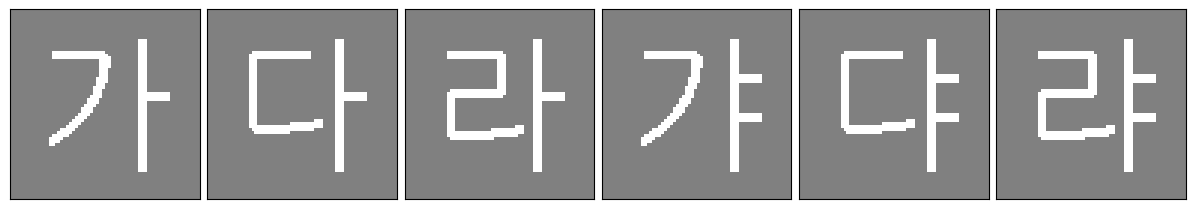

In [5]:
X = binary_image_array/255
n_components = 5 # number of basis vectors

### Start
n_samples = X.shape[0] # each row represents a sample
data_dims = X.shape[1:]
n_features = X[0].size

# Initialize with random nonnegative values
W = np.abs(np.random.normal(size=(n_samples, n_components)))
V = np.abs(np.random.normal(size=(n_components, n_features))) # each row represents a basis vector

W,V = _initialize_nmf(X.copy().reshape(X.shape[0], -1), n_components=n_components, init='nndsvda', random_state=42)

print(X.shape,W.shape,V.shape)

n_row, n_col = 1, 6 # display

plot_gallery(X,n_row=n_row, n_col = n_col)

# Run Top-NMF

In [6]:
# Parameters
lr = 0.005 # learning rate for gradient descent  (Adam: 0.1, SGD: 5)
target_sparsity = None # set to None, if you are not using
epsilon = 1e-10 # for numerical stability
PHmode = "V" # T or V construction
superlevel = True

## specify target PH (or set to None for sparsity)
target_PH = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]

n_iterations = 300
lambda_top = 0.5
gd_iter = 1
tol = 1e-4
tol_count = 30000
n_components = 5
data_dims = (64, 64)

# Create Cubical Complex
cpx = CubicalComplex(superlevel=superlevel, dim=len(data_dims), mode=PHmode)

# Initialize Topological NMF model
model = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=42,
    complex=cpx,
    data_shape=data_dims,
    use_embedding=False
)

# Fit the model
# Flatten data for NMF
X_flat = X.reshape(X.shape[0], -1)
model.fit(
    X_flat,
    n_iterations=n_iterations,
    lr=lr,
    lambda_top=lambda_top,
    target_diagrams=target_PH,
    gd_iter=gd_iter,
    tol=tol,
    tol_count=tol_count,
    verbose=True
)

# Extract learned factors
W = model.W.detach().cpu().numpy()
V = model.V.detach().cpu().numpy()

print(f"Final Loss: {model.losses['approx'][-1]:.4f}")


  0%|          | 0/300 [00:00<?, ?it/s]

Final Loss: 0.0094


# Display Learned Basis Vectors (Top-NMF)

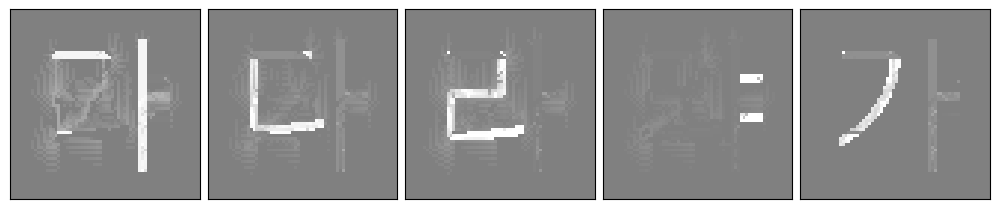

In [7]:
_ = plot_gallery(V.reshape(-1,*data_dims),title="",n_row=1, n_col = 5)

# Quantitative Evaluation (IoU)

## Construct Ground Truth Masks

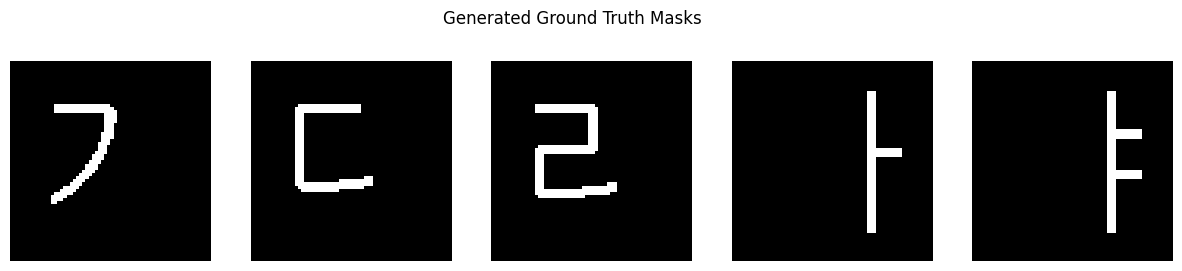

In [ ]:
from TopNMF.evaluation import extract_consonant_vowel_masks

# 1. Configuration for Jamo Composition
# Indices: 0:가, 1:다, 2:라, 3:갸, 4:댜, 5:랴
idx_map = {
    'consonants': {'\u3131': [0, 3], '\u3137': [1, 4], '\u3139': [2, 5]},
    'vowels':     {'\u314f': [0, 1, 2], '\u3151': [3, 4, 5]}
}

# 2. Extract and Intersect Masks (to get the common shape)
ground_truth_masks = {}
if isinstance(X, torch.Tensor):
    X_np = X.detach().cpu().numpy()
else:
    X_np = X

# Process Consonants
for jamo, indices in idx_map['consonants'].items():
    masks = [extract_consonant_vowel_masks(X_np[i].reshape(64,64))[0] for i in indices]
    ground_truth_masks[jamo] = np.logical_and.reduce(masks).astype(int).flatten()

# Process Vowels
for jamo, indices in idx_map['vowels'].items():
    masks = [extract_consonant_vowel_masks(X_np[i].reshape(64,64))[1] for i in indices]
    ground_truth_masks[jamo] = np.logical_and.reduce(masks).astype(int).flatten()

# 3. Visualize Ground Truths
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Generated Ground Truth Masks", y=1.0)
for ax, (jamo, mask) in zip(axes, ground_truth_masks.items()):
    ax.imshow(mask.reshape(64, 64), cmap='gray')
    ax.axis('off')
plt.show()


## Calculate Scores

In [9]:
from TopNMF.evaluation import compute_iou, compute_jamo_iou

# Compute Scores

results, avg_iou = compute_jamo_iou(V, ground_truth_masks)

print("=== Evaluation Results (IoU) ===")
for jamo, info in results.items():
    print(f"Jamo {jamo}: IoU = {info['iou']:.4f} (Matched Basis #{info['basis_index']})")

print("-" * 30)
print(f"Average IoU: {avg_iou:.4f}")

=== Evaluation Results (IoU) ===
Jamo ㄱ: IoU = 0.5152 (Matched Basis #4)
Jamo ㄷ: IoU = 0.2287 (Matched Basis #1)
Jamo ㄹ: IoU = 0.2160 (Matched Basis #2)
Jamo ㅏ: IoU = 0.4818 (Matched Basis #4)
Jamo ㅑ: IoU = 0.3607 (Matched Basis #4)
------------------------------
Average IoU: 0.3605


# Compare with Standard NMF

=== Standard NMF Training (Baseline) ===
Visualizing Standard NMF Basis:

=== Standard NMF Evaluation Results ===
Jamo ㄱ: IoU = 0.5574 (Matched Basis #0)
Jamo ㄷ: IoU = 0.5970 (Matched Basis #1)
Jamo ㄹ: IoU = 0.6574 (Matched Basis #4)
Jamo ㅏ: IoU = 0.7227 (Matched Basis #2)
Jamo ㅑ: IoU = 0.7500 (Matched Basis #3)
------------------------------
Average IoU (Standard NMF): 0.6569


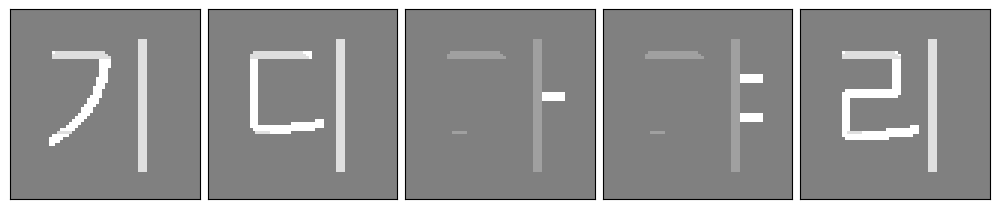

In [10]:
from sklearn.decomposition import NMF

print("=== Standard NMF Training (Baseline) ===")

# 1. Build & Run NMF Model
n_components = 5
model = NMF(n_components=n_components, init='nndsvda', random_state=0)

# Factorize: X ~ W1 * H1
# X was flattened in Appendix 1 (n_samples, n_features)
W1 = model.fit_transform(X.reshape(n_samples, -1)) 
H1 = model.components_ 

# 2. Visualize Basis Vectors
print("Visualizing Standard NMF Basis:")
# H1 needs reshaping to image dimensions for visualization
plot_gallery(H1.reshape(-1, *data_dims), n_row=1, n_col=5)

# 3. Quantitative Evaluation (IoU)
# Note: 'masks' and evaluation functions must be defined in Appendix 2
results_nmf, avg_iou_nmf = compute_jamo_iou(H1, ground_truth_masks)

print("\n=== Standard NMF Evaluation Results ===")
for jamo, info in results_nmf.items():
    print(f"Jamo {jamo}: IoU = {info['iou']:.4f} (Matched Basis #{info['basis_index']})")

print("-" * 30)
print(f"Average IoU (Standard NMF): {avg_iou_nmf:.4f}")